Accuracy: 0.9
Precision: 0.8
Recall: 1.0


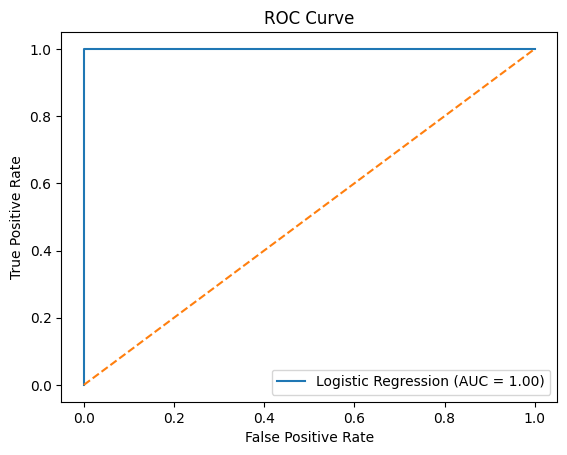

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score

# LOAD DATA
df = pd.read_csv("/content/supply_chain_data.csv")

# CREATE TARGET
threshold = df['Shipping times'].median()
df['Delay'] = (df['Shipping times'] > threshold).astype(int)

df = df.drop(columns=['SKU'])
df = pd.get_dummies(df, drop_first=True)

X = df.drop('Delay', axis=1)
y = df['Delay']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MODEL
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

y_prob = model.predict_proba(X_test)[:,1]

# PREDICTIONS (not probabilities)
y_pred = model.predict(X_test)

# METRICS
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

# ROC CURVE
fpr,tpr,_ = roc_curve(y_test,y_prob)
roc_auc = auc(fpr,tpr)

plt.plot(fpr,tpr,label="Logistic Regression (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Accuracy: 0.7
Precision: 0.6666666666666666
Recall: 0.6666666666666666


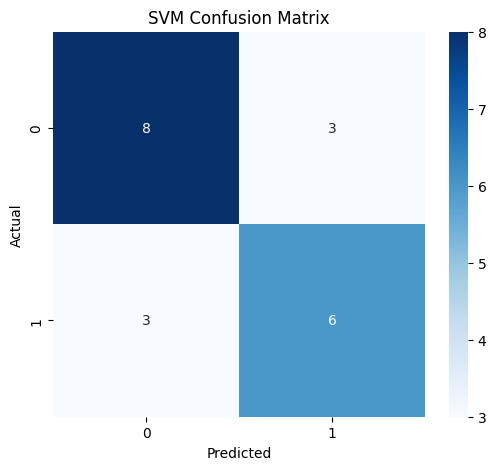

In [6]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# FIX TARGET
threshold = df['Shipping times'].median()
df['Delay'] = ((df['Shipping times'] + np.random.randn(len(df))) > threshold).astype(int)

# SPLIT AGAIN
X = df.drop('Delay', axis=1)
y = df['Delay']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# SCALING
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SVM MODEL (balanced)
svm_model = SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced')

svm_model.fit(X_train, y_train)

# PREDICTIONS
y_pred_svm = svm_model.predict(X_test)

# METRICS
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))

# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

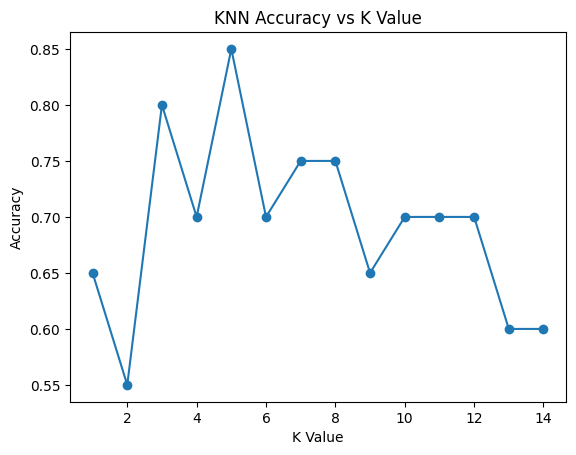

Best K: 5
Accuracy: 0.85
Precision: 1.0
Recall: 0.6666666666666666


In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np
import matplotlib.pyplot as plt

# STORE ACCURACY VALUES
accuracy = []

# TRY DIFFERENT K VALUES
for k in range(1, 15):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy.append(accuracy_score(y_test, y_pred))

# PLOT GRAPH
plt.plot(range(1, 15), accuracy, marker='o')

plt.title("KNN Accuracy vs K Value")
plt.xlabel("K Value")
plt.ylabel("Accuracy")

plt.show()

# FIND BEST K
best_k = np.argmax(accuracy) + 1
print("Best K:", best_k)

# FINAL MODEL WITH BEST K
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

# METRICS
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))

Logistic Regression -> Accuracy: 0.85 Precision: 0.8 Recall: 0.8888888888888888
SVM -> Accuracy: 0.7 Precision: 0.6666666666666666 Recall: 0.6666666666666666
KNN -> Accuracy: 0.85 Precision: 1.0 Recall: 0.6666666666666666


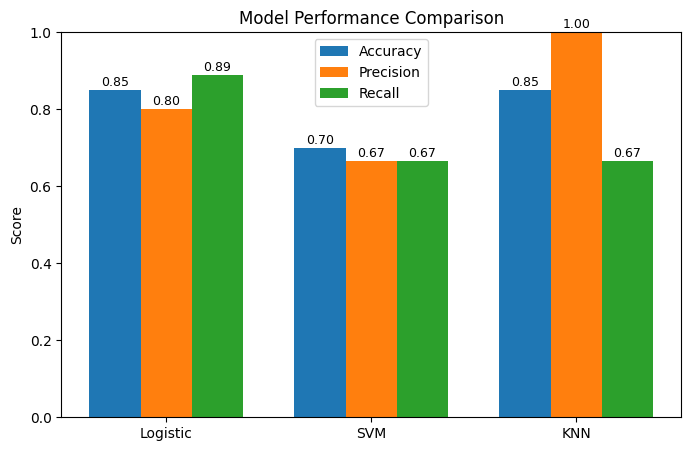

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np
import matplotlib.pyplot as plt

# Predictions
log_pred = model.predict(X_test)
svm_pred = svm_model.predict(X_test)
knn_pred = knn.predict(X_test)

# Metrics
acc_log = accuracy_score(y_test, log_pred)
acc_svm = accuracy_score(y_test, svm_pred)
acc_knn = accuracy_score(y_test, knn_pred)

prec_log = precision_score(y_test, log_pred)
prec_svm = precision_score(y_test, svm_pred)
prec_knn = precision_score(y_test, knn_pred)

rec_log = recall_score(y_test, log_pred)
rec_svm = recall_score(y_test, svm_pred)
rec_knn = recall_score(y_test, knn_pred)

# PRINT VALUES (important for report)
print("Logistic Regression -> Accuracy:", acc_log, "Precision:", prec_log, "Recall:", rec_log)
print("SVM -> Accuracy:", acc_svm, "Precision:", prec_svm, "Recall:", rec_svm)
print("KNN -> Accuracy:", acc_knn, "Precision:", prec_knn, "Recall:", rec_knn)

# Data
labels = ["Logistic", "SVM", "KNN"]

accuracy = [acc_log, acc_svm, acc_knn]
precision = [prec_log, prec_svm, prec_knn]
recall = [rec_log, rec_svm, rec_knn]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8,5))

bars1 = plt.bar(x - width, accuracy, width, label="Accuracy")
bars2 = plt.bar(x, precision, width, label="Precision")
bars3 = plt.bar(x + width, recall, width, label="Recall")

plt.xticks(x, labels)

plt.title("Model Performance Comparison")
plt.ylabel("Score")

# ADD VALUES ON BARS (looks professional)
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                 f"{height:.2f}", ha='center', fontsize=9)

plt.legend()
plt.ylim(0,1)

plt.show()